### Importy a nazvy tickerov firiem

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, date
import pickle
import os
import dateutil.parser
import random
import matplotlib.pyplot as plt

In [ ]:
# MU = Micron Technology, Inc.
#          Apple,   AMD,  Intel,   MU,  Amazon, Nvidia, Oracle
tickers = ['AAPL', 'AMD', 'INTC',	'MU',	'AMZN', 'NVDA', 'ORCL']

### Ak stahujes data, spusti tieto bunky

In [ ]:
start_date = datetime(2020,1,1)
end_date = datetime(2026,1,1)
daily_intervals_companies = yf.download(tickers=tickers, start=start_date, end=end_date, interval='1d')

/tmp/ipykernel_9191/358672178.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  daily_intervals_companies = yf.download(tickers=tickers, start=start_date, end=end_date, interval='1d')
[*********************100%***********************]  7 of 7 completed


In [ ]:
sap500 = yf.download(tickers='^GSPC', start=start_date, end=end_date, interval='1d')

/tmp/ipykernel_9191/2921175456.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sap500 = yf.download(tickers='^GSPC', start=start_date, end=end_date, interval='1d')
[*********************100%***********************]  1 of 1 completed


### Ak pouzivas CSV subory, tak pouzi az tieto bunky

In [ ]:
daily_intervals_companies = pd.read_csv('/content/daily_intervals_pdab.csv', index_col=0, header=[0,1])
sap500 = pd.read_csv('/content/sap500_pdab.csv', index_col=0, header=[0,1])

In [ ]:
daily_intervals_companies.index = pd.to_datetime(daily_intervals_companies.index)
sap500.index = pd.to_datetime(sap500.index)

### Zbavovanie sa neopouzivanych stlpcov

In [ ]:
sap500.drop(columns=['High'],inplace=True)

In [ ]:
sap500.drop(columns=['Low'],inplace=True)

In [ ]:
sap500.drop(columns=['Open'],inplace=True)

In [ ]:
sap500.drop(columns=['Volume'],inplace=True)

### Metody na obchodovanie

In [ ]:
def create_moving_window(df):
    # Generate random length of moving median window.
    short_term_period = int(random.uniform(0,1) * 20 + 30)
    long_term_period = short_term_period * 4
    company_cols = [col[1] for col in df.columns if col[0] == 'Close' and 'return' not in col[1]]

    for firma in company_cols:
        short_col = ('Close', f'{firma}-median_short')
        long_col = ('Close', f'{firma}-median_long')
        trend_col = ('Close', f'{firma}-up_or_down')

        df.loc[:, short_col] = df.loc[:,('Close', f'{firma}')].rolling(short_term_period).median()
        df.loc[:, long_col] = df.loc[:,('Close', f'{firma}')].rolling(long_term_period).median()
        df.loc[:, trend_col] = df.loc[:,short_col] > df.loc[:,long_col]
    return short_term_period, long_term_period

In [ ]:
def vynosy_cien_akcii(df):
    cols = [col[1] for col in df.columns if col[0] == 'Close']
    for col_helper in cols:
        # calculating return as percentaul change of 2 consecutive prices of all stocks
        df.loc[:,('Close',f'{col_helper}-return')] = df.loc[:,('Close',f'{col_helper}')].pct_change()

In [ ]:
def nakup_akcie(priebezne_kapitaly, cena_akcie, aktualny_datum, vyvoj_cien_akcie, bought, company):
    # buy
    bought[company] = True
    # writing record of buying stocks
    vyvoj_cien_akcie[company][aktualny_datum] = {'stav':'kupene',
                                                 'pocet_akcii':priebezne_kapitaly[company] / cena_akcie,
                                                 'priebezne kapitaly':
                                                 {aktualny_datum:priebezne_kapitaly[company]}}

In [ ]:
def zapis_zmeny_akcie(priebezne_kapitaly, new_return, stock_prices, actual_date, buy_date, company):
    # Updating stock prices for bought stocks
    priebezny_kapital = priebezne_kapitaly[company]
    priebezny_kapital *= (1 + new_return)
    priebezne_kapitaly[company] = priebezny_kapital
    stock_prices[company][buy_date[company]]['priebezne kapitaly'][actual_date] = priebezny_kapital

In [ ]:
def predaj_akcie(priebezne_kapitaly, cena_akcie, actual_date,
                 buy_dates, stock_prices, bought, company_column):
    # Record that stocks of the company has been sold.
    stock_prices[company_column][buy_dates[company_column]]['stav'] = 'predane'
    bought[company_column] = False
    buy_dates[company_column] = ''

In [ ]:
def manazovanie_nakupu_a_predaja(priebezne_kapitaly, cena_akcie, new_return, stock_prices,
                                 actual_date, buy_dates, up, bought, company_column):
    # If a stock is bought, then its price should change as market tells.
    if bought[company_column]:
        zapis_zmeny_akcie(priebezne_kapitaly, new_return, stock_prices, actual_date,
                                                          buy_dates, company_column)
        # sell
        if not up:
            predaj_akcie(priebezne_kapitaly, cena_akcie, actual_date, buy_dates,
                         stock_prices, bought, company_column)

    # If stock was not bought, write it as if it was not bought.
    else:
        # buy
        if up:
            nakup_akcie(priebezne_kapitaly, cena_akcie, actual_date,
                        stock_prices, bought, company_column)
            buy_dates[company_column] = actual_date
        else:
            stock_prices[company_column][actual_date] = {'stav':'cakam na nakup',
                                                          'priebezny kapital':priebezne_kapitaly[company_column]}

In [ ]:
def mozny_krach(stlpce_firiem, stock_prices, priebezne_kapitaly, bought, buy_dates):
    skrachovane_firmy = []
    # ak sa najde nejaky zaporny kapital, tak sa vymazu informacie o danej firme
    if any(kapital <= 0 for kapital in priebezne_kapitaly.values()):
        debt = 0
        for firma in stlpce_firiem:
            if priebezne_kapitaly[firma] <= 0:
                skrachovane_firmy.append(firma)
                debt += abs(priebezne_kapitaly[firma])
                stlpce_firiem.pop(firma)
                priebezne_kapitaly.pop(firma)
                bought.pop(firma)
                buy_dates.pop(firma)
                stock_prices.pop(firma)
        return debt
    return 0


In [ ]:
def zapis_zostatku(zostatky, datum_zostatku):
    if ' ' in zostatky.keys():
        zostatky[datum_zostatku] = zostatky[' ']
        zostatky.pop(' ')
    else:
        posledny_den = sorted(list(zostatky.keys()))[-1]
        zostatky[datum_zostatku] = zostatky[posledny_den] * (1 + 0.0001) if datum_zostatku.day != posledny_den.day else zostatky[posledny_den]

In [ ]:
def trading(vyvoj_cien_akcii, long_term_median_period, stlpce_firiem, stock_prices, priebezne_kapitaly,
            bought, buy_dates, zostatky):
    '''
      Simulates trading for every interval.
      vyvoj_cien_akcii: Pandas.DataFrame - time series of stock prices for given period
      long_term_median_period: int - length of long-term moving median period
      stlpce_firiem: list - list of companies' names
      stock_prices: dict - records about companies' transactions
      priebezne_kapitaly: dict - records about sum of all companies' stocks respectively
      bought: dict - records whether a concrete company stocks has been bough recently or not
      zostatky: dict - amount of money that has not been invested and are being capitalized over time (zúročené)
    '''
    dates = vyvoj_cien_akcii.index
    prvy_uvazovany_datum = dates[long_term_median_period - 1]
    datum_zostatku = prvy_uvazovany_datum
    # dates from the first date when long-term moving median is not NaN
    dates_investing = list(filter(lambda x: x>=prvy_uvazovany_datum, list(dates)))
    for date in dates_investing:
       # we need to skip first values in order to get enough values
       # to calculate long_term_average
       bankrupt = mozny_krach(stlpce_firiem, stock_prices, priebezne_kapitaly, bought, buy_dates)
       posledny_den = sorted(list(zostatky.keys()))[-1]
       zostatky[posledny_den] = zostatky[posledny_den] if bankrupt == 0 else zostatky[posledny_den] - bankrupt
       # asi sa nestane
       if zostatky[posledny_den] <= 0:
           # doimplementovat ale asi netreba
           pass
       aktualny_riadok = vyvoj_cien_akcii['Close'].loc[date]
       for company_column in stlpce_firiem:
          new_return = aktualny_riadok[f'{company_column}-return']
          # we need to find out whether we are UP or DOWN
          up = aktualny_riadok[f'{company_column}-up_or_down']

          manazovanie_nakupu_a_predaja(priebezne_kapitaly,
                                        aktualny_riadok[company_column], # actual stock price
                                        new_return,                      # actual return
                                        stock_prices,                    #
                                        date,                            # actual date
                                        buy_dates,                       # buy dates of companies
                                        up,                              # information about relationship of short-term and long-term moving medians
                                        bought,                          # information about whether we bought stocks/sold stocks/are watinging to buy stocks
                                        company_column)                  # nazov firmy
       zapis_zostatku(zostatky, date)

In [ ]:
def median_crossover(vyvoj_cien_akcii, vstupny_kapital):
    '''Runs median_crossover simulation for vyvoj_cien_akcii
       vyvoj_cien_akcii: Pandas.DataFrame
       vstupny_kapital: float'''
    stlpce_firiem = list(map(lambda x: x[1],filter(lambda x: x[0]=='Close',vyvoj_cien_akcii.columns)))
    vynosy_cien_akcii(vyvoj_cien_akcii)
    short_term_median_period, long_term_median_period = create_moving_window(vyvoj_cien_akcii)
    zostatok = 0.1 * vstupny_kapital
    vstupny_kapital *= 0.9
    # creating variables for all companies
    stock_prices = {nazov_firmy:{} for nazov_firmy in stlpce_firiem}
    pocet_firiem = len(stlpce_firiem)
    # Rounding to whole number part
    priebezny_kapital = vstupny_kapital // pocet_firiem
    zostatok += vstupny_kapital - (priebezny_kapital * pocet_firiem)
    zostatky_time_series = dict()
    zostatky_time_series[' '] = zostatok
    vstupny_kapital = priebezny_kapital * pocet_firiem

    # information about all companies
    priebezne_kapitaly = {firma:priebezny_kapital for firma in stlpce_firiem}
    bought = {firma:False for firma in stlpce_firiem}

    buy_dates = {firma:'' for firma in stlpce_firiem}
    trading(vyvoj_cien_akcii, long_term_median_period, stlpce_firiem, stock_prices, priebezne_kapitaly,
            bought, buy_dates, zostatky_time_series)
    return stock_prices, zostatky_time_series

In [ ]:
def create_copy_only_close(df_helper):
    # Create a copy of df with only Close column for companies
    df_helper2 = df_helper.copy()
    df_helper2.drop(columns=['Volume'],inplace=True)
    df_helper2.drop(columns=['High'],inplace=True)
    df_helper2.drop(columns=['Low'],inplace=True)
    df_helper2.drop(columns=['Open'],inplace=True)
    return df_helper2

In [ ]:
# aby sa neprepisali povodne data
daily_stocks = create_copy_only_close(daily_intervals_companies)

In [ ]:
output_of_investing, zostatky = median_crossover(daily_stocks, 100_000)

### Report transakcii

In [ ]:
transakcie_firiem = []
for firma, priebezny_kapital_firmy_helper in output_of_investing.items():
    # extrahovat JSON v spravnom formate
    report_transakcie = dict()
    for datum, transakcia in priebezny_kapital_firmy_helper.items():
        if transakcia['stav'] in ('predane', 'kupene'):
            pocet_akcii = transakcia['pocet_akcii']
            # datumy, casy a ceny nakupu/predaja
            datumy_medzi_nakup_predaj = sorted(list(transakcia['priebezne kapitaly'].keys()))
            datum_nakupu = datumy_medzi_nakup_predaj[0]
            datum_predaja = datumy_medzi_nakup_predaj[-1]
            cas_nakupu = datum_nakupu.time().strftime("%X")
            cas_predaja = datum_predaja.time().strftime("%X")
            cena_nakupu = transakcia['priebezne kapitaly'][datum_nakupu]
            cena_predaja = transakcia['priebezne kapitaly'][datum_predaja]
            datum_nakupu = datum_nakupu.date().strftime("%#d.%#m.%Y")
            datum_predaja = datum_predaja.date().strftime("%#d.%#m.%Y")
            # nahravanie slovnika s informaciou o tom, ze sa nakupili akcie
            # nakup - ak je predane, tak sa muselo aj nakupit aj predat
            transakcie_firiem.append({'Dátum':datum_nakupu,'Čas':cas_nakupu,'Akcia':firma,'Množstvo':pocet_akcii,'Cena':cena_nakupu,'BUY/SELL':'BUY'})
            if transakcia['stav'] == 'predane':
                # predaj
                transakcie_firiem.append({'Dátum':datum_predaja,'Čas':cas_predaja,'Akcia':firma,'Množstvo':pocet_akcii,'Cena':cena_predaja,'BUY/SELL':'SELL'})


In [ ]:
# Formát: Dátum, Čas, Akcia, Množstvo, Cena
# Vytvorenie DF reportu v tabulkovej podobe
df_report = pd.DataFrame(data=transakcie_firiem, columns=["Dátum", "Čas", "Akcia", "Množstvo", "Cena"])

In [ ]:
def sort_by_date_time(df_helper):
    # zoradzovanie zaznamov pomocou noveho stlpca Date_time, aby sa dal cas rozumne porovnavat
    df_helper["Date_time"] = pd.to_datetime(df_helper["Dátum"] + " " + df_helper["Čas"], format="%d.%m.%Y %H:%M:%S")
    df_helper.sort_values('Date_time', inplace=True)
    df_helper.drop(columns=['Date_time'], inplace=True)

In [ ]:
sort_by_date_time(df_report)

In [ ]:
df_report

,Dátum,Čas,Akcia,Množstvo,Cena
0,23.09.2020,00:00:00,AAPL,123.739721,12857.000000
22,23.09.2020,00:00:00,AMZN,85.717336,12857.000000
50,23.09.2020,00:00:00,ORCL,236.175348,12857.000000
45,23.09.2020,00:00:00,NVDA,1063.834835,12857.000000
13,23.09.2020,00:00:00,AMD,172.046025,12857.000000
...,...,...,...,...,...
60,08.07.2025,00:00:00,ORCL,115.844944,26895.796368
21,11.07.2025,00:00:00,AMD,178.368211,26116.673183
37,16.07.2025,00:00:00,INTC,463.611209,10519.338590
12,09.09.2025,00:00:00,AAPL,73.082019,17078.454678



### Graf výkonnosti

In [ ]:
# zbieranie jednotlivych vysok cien pre jednotlive akcie
vyvoje_cien_akcii_firiem = dict()
for company in output_of_investing.keys():
    vyvoj_akcie = output_of_investing[company]
    vyvoj_cien_akcie_firmy = dict()
    for datum in sorted(list(vyvoj_akcie.keys())):
        report = vyvoj_akcie[datum]
        if report['stav'] == 'cakam na nakup':
            vyvoj_cien_akcie_firmy[datum] = report['priebezny kapital']
        elif report['stav'] in ('kupene','predane'):
            for datum_nakup_predaj in sorted(list(report['priebezne kapitaly'].keys())):
                vyvoj_cien_akcie_firmy[datum_nakup_predaj] = report['priebezne kapitaly'][datum_nakup_predaj]
    vyvoje_cien_akcii_firiem[company] = vyvoj_cien_akcie_firmy

# spajanie vsetkych akcii do jedneho DataFrame
dfs = []
for t in tickers:
    s = pd.Series(vyvoje_cien_akcii_firiem[t], name=t)
    dfs.append(s)

df_companies = pd.concat(dfs, axis=1)

### Zobrazenie hodnoty portfolia v čase

In [ ]:
df_companies['Price of entire portfolio'] = df_companies[tickers].sum(axis=1)

In [ ]:
df_companies

,AAPL,AMD,INTC,MU,AMZN,NVDA,ORCL,Price of entire portfolio
2020-09-23,12857.000000,12857.000000,12857.000000,12857.000000,12857.000000,12857.000000,12857.000000,89999.000000
2020-09-24,12989.026673,13044.529537,12857.000000,12857.000000,12942.417817,13094.814023,12931.140846,90715.928895
2020-09-25,13476.324518,13429.912265,12857.000000,12857.000000,13265.314874,13652.366125,13040.171395,92578.089176
2020-09-28,13797.988129,13674.218617,12857.000000,12857.000000,13603.555407,13823.366829,12992.197377,93605.326358
2020-09-29,13693.568578,14068.202858,12857.000000,12857.000000,13478.537008,14025.656315,12968.209917,93948.174676
...,...,...,...,...,...,...,...,...
2025-12-24,19973.477711,38356.298977,16764.181263,50217.475645,19670.057203,189802.195936,20547.420628,355331.107363
2025-12-26,19943.569573,38347.382744,16782.726136,49886.408826,19681.907603,191734.327413,20547.420628,356923.742922
2025-12-29,19969.833424,38457.970164,17005.259305,51585.357284,19643.817124,189409.725491,20547.420628,356619.383419
2025-12-30,19920.227397,38409.809985,17292.697759,51280.436612,19682.753598,188725.428287,20547.420628,355858.774266


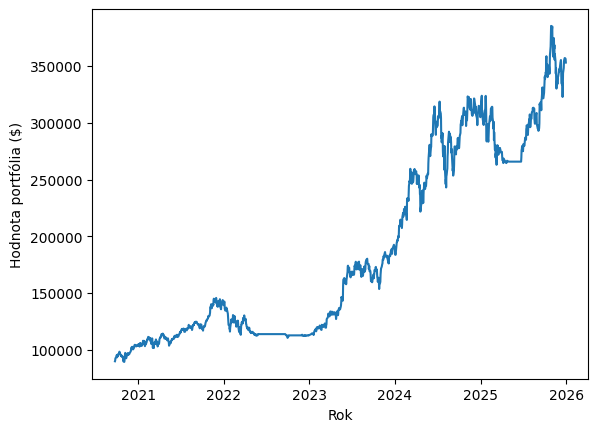

In [ ]:
# Cena celkoveho portfolia v dolaroch
plt.plot(df_companies.index, df_companies['Price of entire portfolio'])
plt.xlabel('Rok')
plt.ylabel('Hodnota portfólia ($)')
plt.show()

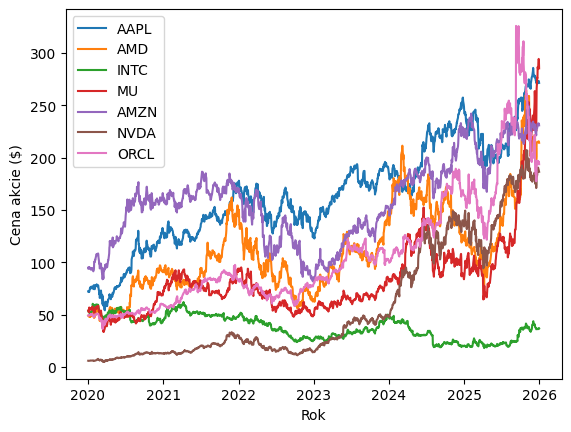

In [ ]:
# Graficke znazornenie cien jednotlivych akcii
for ticker in tickers:
    plt.plot(daily_stocks.index, daily_stocks.loc[:,('Close',ticker)])
plt.legend(tickers)
plt.xlabel("Rok")
plt.ylabel("Cena akcie ($)")
plt.show()

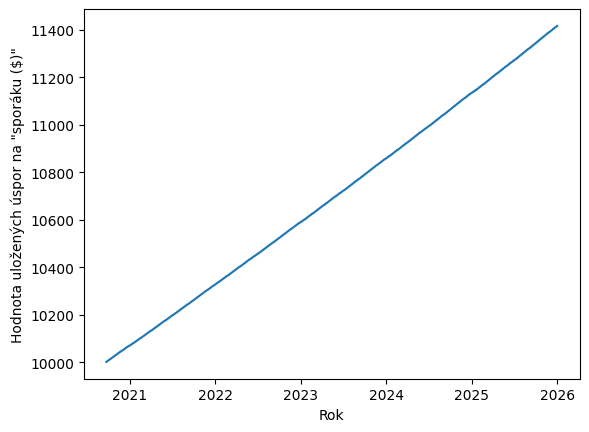

In [ ]:
# Zostatok penazi ulozenych na sporaku
plt.plot([datum for datum in sorted(list(zostatky.keys()))], [zostatky[datum] for datum in sorted(list(zostatky.keys()))])
plt.xlabel("Rok")
plt.ylabel('Hodnota uložených úspor na "sporáku ($)"')
plt.show()

### Porovnanie s baseline portfóliom S&P 500

In [ ]:
sap500['Return'] = sap500['Close'].pct_change()

In [ ]:
sap500

Price,Close,Return,Cum_returns,Investment
Ticker,^GSPC,,,
Date,,,,
2020-01-02,3257.850098,NaN,NaN,NaN
2020-01-03,3234.850098,NaN,0.992940,89364.611649
2020-01-06,3246.280029,NaN,0.996449,89680.370146
2020-01-07,3237.179932,NaN,0.993655,89428.974666
2020-01-08,3253.050049,NaN,0.998527,89867.395865
...,...,...,...,...
2025-12-24,6932.049805,NaN,2.127799,191501.899633
2025-12-26,6929.939941,NaN,2.127151,191443.613436


In [ ]:
sap500['Return'] += 1

In [ ]:
sap500['Cum_returns'] = np.cumprod(sap500['Return'])

In [ ]:
initial_investment = 90_000

In [ ]:
sap500['Investment'] = initial_investment * sap500['Cum_returns']

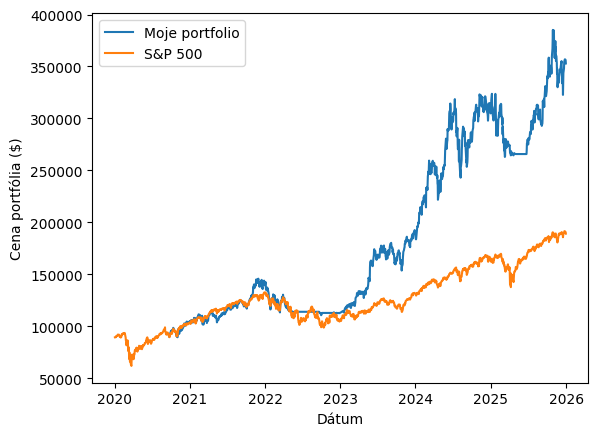

In [ ]:
plt.plot(df_companies.index, df_companies['Price of entire portfolio'])
plt.plot(sap500.index, sap500['Investment'])
plt.xlabel("Dátum")
plt.ylabel("Cena portfólia ($)")
plt.legend(["Moje portfolio","S&P 500"])

### Porovnanie so sporákom

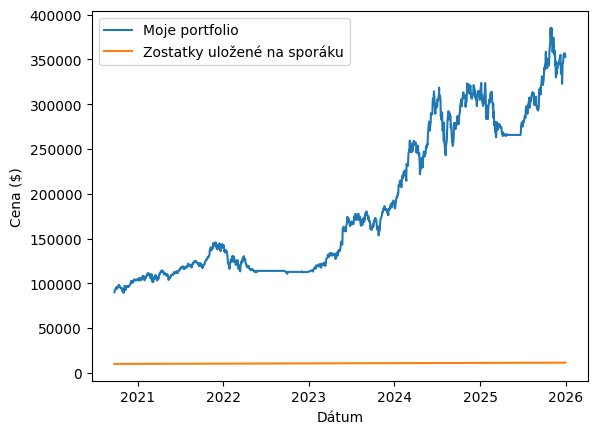

In [ ]:
# Graficke porovnanie s baseline portfoliami (sporak)
plt.plot(df_companies.index, df_companies['Price of entire portfolio'])
plt.plot([datum for datum in sorted(list(zostatky.keys()))], [zostatky[datum] for datum in sorted(list(zostatky.keys()))])
plt.xlabel("Dátum")
plt.ylabel("Cena ($)")
plt.legend(["Moje portfolio","Zostatky uložené na sporáku"])
plt.show()